<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Decision_Tree_and_KNN_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Options when reading in CSV files**

If I set stringAsFactors = FALSE, most of the variables will be read as character (chr) rather than factor

In [6]:
weather.data = read.csv("Weather.csv", as.is = TRUE)

str(weather.data)

'data.frame':	14 obs. of  5 variables:
 $ Outlook : chr  "Sunny " "Sunny " "Overcast " "Rainy " ...
 $ Temp.   : chr  "Hot " "Hot " "Hot " "Mild " ...
 $ Humidity: chr  "High " "High " "High " "High " ...
 $ Windy   : chr  "FALSE " "TRUE " "FALSE " "FALSE " ...
 $ Play    : chr  "No " "No " "Yes " "Yes " ...


On the other hand....

In [7]:
weather.data = read.csv ("Weather.csv", stringsAsFactors = TRUE)

str(weather.data)

'data.frame':	14 obs. of  5 variables:
 $ Outlook : Factor w/ 3 levels "Overcast ","Rainy ",..: 3 3 1 2 2 2 1 3 3 2 ...
 $ Temp.   : Factor w/ 3 levels "Cool ","Hot ",..: 2 2 2 3 1 1 1 3 1 3 ...
 $ Humidity: Factor w/ 2 levels "High ","Normal ": 1 1 1 1 2 2 2 1 2 2 ...
 $ Windy   : Factor w/ 2 levels "FALSE ","TRUE ": 1 2 1 1 1 2 2 1 1 1 ...
 $ Play    : Factor w/ 2 levels "No ","Yes ": 1 1 2 2 2 1 2 1 2 2 ...


To change the variable names

In [8]:
weather.data = read.csv ("Weather.csv",
                         stringsAsFactors = TRUE,
                         col.names = c ("Outlook", "Temp", "Hum", "Wind", "Play"))

There are many other options. Use ?read.csv to see them

Note that you can also change the column names after you read in the data

In [9]:
colnames (weather.data) = c("outlook", "temp", "hum", "wind", "play")

In [10]:
View (weather.data)

outlook,temp,hum,wind,play
<fct>,<fct>,<fct>,<fct>,<fct>
Sunny,Hot,High,FALSE,No
Sunny,Hot,High,TRUE,No
Overcast,Hot,High,FALSE,Yes
Rainy,Mild,High,FALSE,Yes
Rainy,Cool,Normal,FALSE,Yes
Rainy,Cool,Normal,TRUE,No
Overcast,Cool,Normal,TRUE,Yes
Sunny,Mild,High,FALSE,No
Sunny,Cool,Normal,FALSE,Yes


#**Training Decision Tree**

Let's build a decision tree using the popular rpart package that builds CART-like trees (using Gini index to decide on splits)

In [11]:
pkgs <- c("rpart")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [12]:
library(rpart)

First build a tree using the default parameters

In [14]:
cart.model = rpart (play~., data = weather.data)

#print a concise summary of cart.model object
cart.model

n= 14 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 14 5 Yes  (0.3571429 0.6428571) *




---


Cart.model table


*   n=14 (total observations/rows)
*   node: the node number in the tree
*   split: the condition used to split the data at the node (outlook = Sunny)
*   n: number of observations in that node
*   loss: number of misclassified observations if the majority class is predicted (if yes is predicted, 5 errors)
*   yval: the predicted class for the node (the majority class)
*   yprob: the probablities of each class within that node
*   *denotes terminal node indicates this is a terminal node of the tree

---

In [15]:
summary (cart.model)

Call:
rpart(formula = play ~ ., data = weather.data)
  n= 14 

    CP nsplit rel error xerror xstd
1 0.01      0         1      0    0

Node number 1: 14 observations
  predicted class=Yes   expected loss=0.3571429  P(node) =1
    class counts:     5     9
   probabilities: 0.357 0.643 



---

cart.model summary table

*   call: rpart(formula = play ~ ., data = weather.data) (the command used to build the model

*   CP: complexity parameter (0.01)

*   nsplit: 0 splits

*   rel error: 1 (relative error: the error rate of the current tree relative to the error rate of a tree with no splits; 1 means perform no better; as the tree grows and make more accurate predictions, the error will decrease)

*   xerror: 0 (cross-validation error: estimate the prediction error for the tree. cross-validation is performed to get a more robust estimate of how well the tree will generalize to new, unseen data. it's often used to help determine the optimal tree size for pruning)

*   xstd : 0 (cross-validation standard deviation: this is the standard deviation of the xerror. It provides a measure of the variability or uncertainty around xerror estimate. High: high variance, low: more reliable)

node number 1 contains all 14 observations

expected loss: the proportion of observations that are not the predicted class (5 no/14)

P (node) = 1 (probability of node: the proportion of the total observations from the original dataset that fall into that specific node: 14/14 = 1)

---

We have to change the "minsplit" because the default value would not allow any splits for out data

In [16]:
cart.model = rpart (play~., data = weather.data,
                    control = rpart.control (minsplit = 1))

cart.model

n= 14 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 14 5 Yes  (0.3571429 0.6428571)  
   2) outlook=Rainy ,Sunny  10 5 No  (0.5000000 0.5000000)  
     4) hum=High  5 1 No  (0.8000000 0.2000000)  
       8) outlook=Sunny  3 0 No  (1.0000000 0.0000000) *
       9) outlook=Rainy  2 1 No  (0.5000000 0.5000000)  
        18) wind=TRUE  1 0 No  (1.0000000 0.0000000) *
        19) wind=FALSE  1 0 Yes  (0.0000000 1.0000000) *
     5) hum=Normal  5 1 Yes  (0.2000000 0.8000000)  
      10) wind=TRUE  2 1 No  (0.5000000 0.5000000)  
        20) outlook=Rainy  1 0 No  (1.0000000 0.0000000) *
        21) outlook=Sunny  1 0 Yes  (0.0000000 1.0000000) *
      11) wind=FALSE  3 0 Yes  (0.0000000 1.0000000) *
   3) outlook=Overcast  4 0 Yes  (0.0000000 1.0000000) *

Ok, now we have a tree, let's use it to predict and output the confusion matrix

In [18]:
weather.predictions = predict (cart.model, weather.data, type = "class")

table (weather.data$play, weather.predictions)

      weather.predictions
       No  Yes 
  No     5    0
  Yes    0    9

predict behaves different in rpart. It didn't specific type in rpart, so the default type is "prob" or "vector" factors.

The training error is 0. Is this a good thing?

#**Visualizing Decision Trees**

R is great at visualization (especially using ggplot2) and the rpart.plot package

In [19]:
pkgs <- c("rpart.plot")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



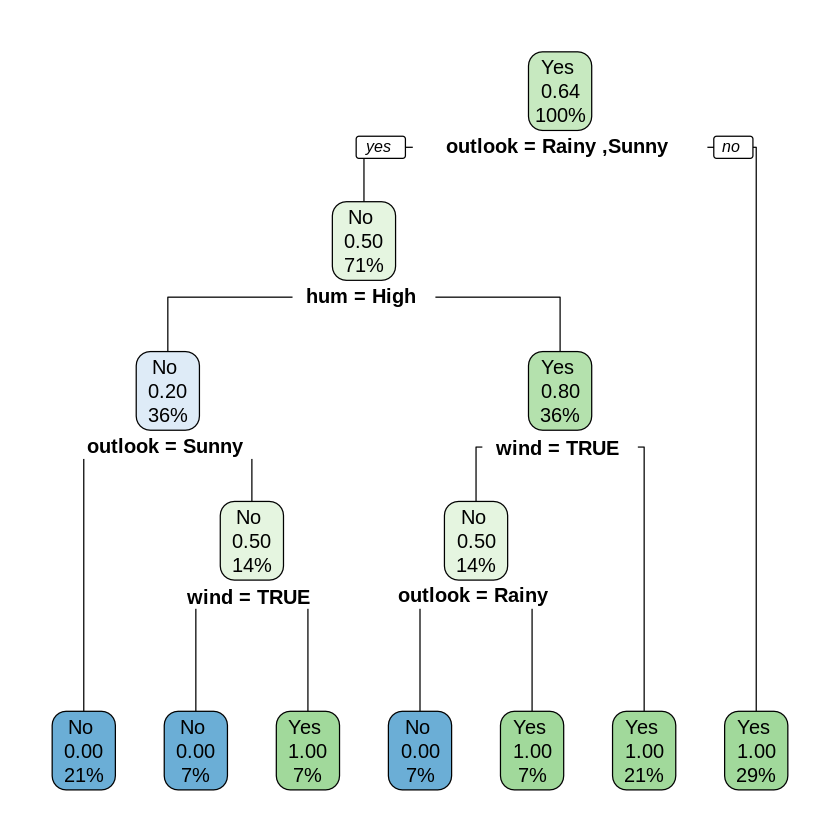

In [20]:
library (rpart.plot)

rpart.plot (cart.model)

There are many parameters that you can use to change the look of the tree

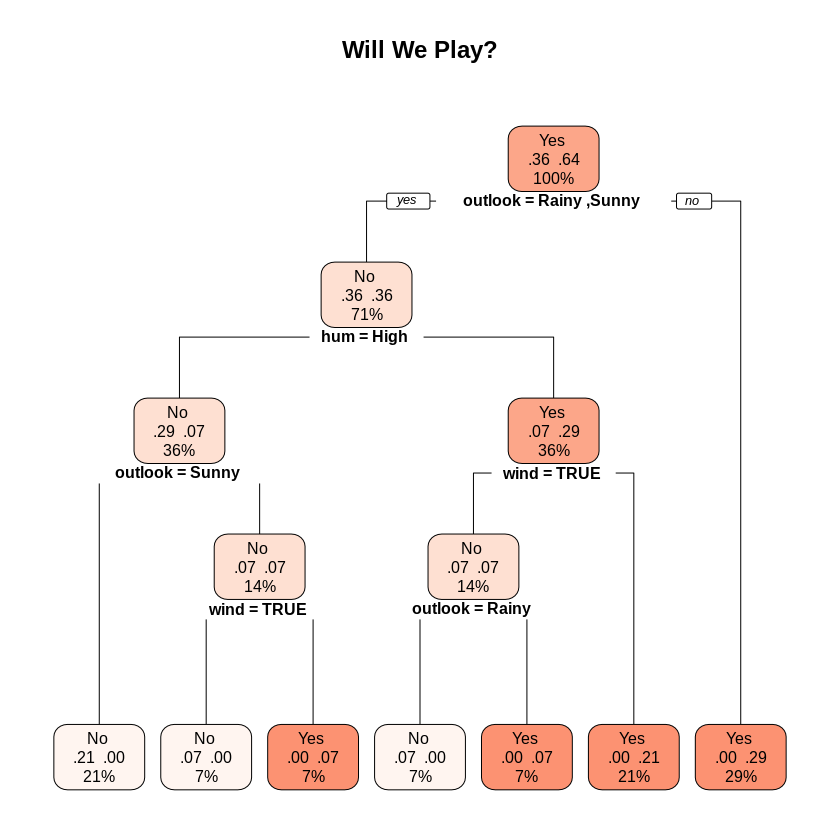

In [22]:
rpart.plot (cart.model, extra = 109,
            cex = 0.8,
            box.palette = "Reds",
            main = "Will We Play?")

#extra = 100 displays the predicted class for each node
#extra = 109: display the percentage of observations in the node that belong
   #to the predicted class
#cex : font size
#box.palette : color palette for nodes
# main: title

#**Parameter Tuning**

Note that the cp parameter is a pre-pruning parameter. It works by not attempting any splits that doesn't decrease the split criterion by at least that amount. For example,if we are using gini index (default), the gini index must be reduced by at least amount cp for each split. If we are using information gain then entropy must be reduced by at least cp for each split.

---


There are three ways in which we can tune a decision tree:

a) The cp parameter (or other parameter determining the amount of pruning)

b) The minimum number of data points in a split (don't recommend)

 c) The set of variables used as predictor/independent variables

 ---

 How does each of those affect the size/complexity of the tree?

We created a DT with the default cp parameter value:

In [23]:
cart.model$control$cp

[1] 0.01

 If we increase cp value then fewer splits will be created (pre-pruning)

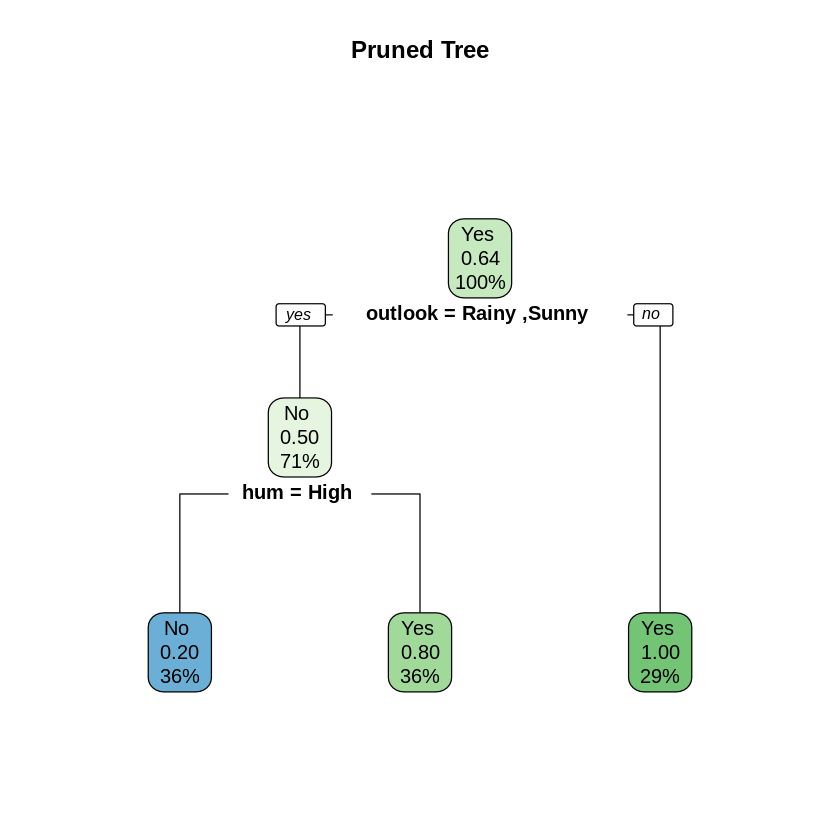

In [24]:
cart.model.pruned = rpart (play~., data = weather.data,
                           control = rpart.control (minsplit = 1, cp = 0.1))

rpart.plot (cart.model.pruned, main = "Pruned Tree")

For root node, 0.64 is the proportion of the majority class within that node (9/14)

100% is the percentage of the total dataset that contained within that node

In [25]:
summary (cart.model.pruned)

Call:
rpart(formula = play ~ ., data = weather.data, control = rpart.control(minsplit = 1, 
    cp = 0.1))
  n= 14 

   CP nsplit rel error xerror      xstd
1 0.3      0       1.0    1.0 0.3585686
2 0.1      2       0.4    1.6 0.3703280

Variable importance
    hum outlook    temp 
     39      38      23 

Node number 1: 14 observations,    complexity param=0.3
  predicted class=Yes   expected loss=0.3571429  P(node) =1
    class counts:     5     9
   probabilities: 0.357 0.643 
  left son=2 (10 obs) right son=3 (4 obs)
  Primary splits:
      outlook splits as  RLL, improve=1.4285710, (0 missing)
      hum     splits as  LR,  improve=1.2857140, (0 missing)
      wind    splits as  RL,  improve=0.4285714, (0 missing)
      temp    splits as  RLR, improve=0.2285714, (0 missing)

Node number 2: 10 observations,    complexity param=0.3
  predicted class=No    expected loss=0.5  P(node) =0.7142857
    class counts:     5     5
   probabilities: 0.500 0.500 
  left son=4 (5 obs) right son

xerror higher from 0 for unsplit tree to 1 to 1.6. Possibly underfitting or aggressive pruning or cross-validation resulrs can be highly unstable and variable due to small dataset

Rel error shows better results, training error of the tree(similar to gini index: impurity measure of a node, 0 means pure)

---

The higher we set the cp value the more we prune the tree

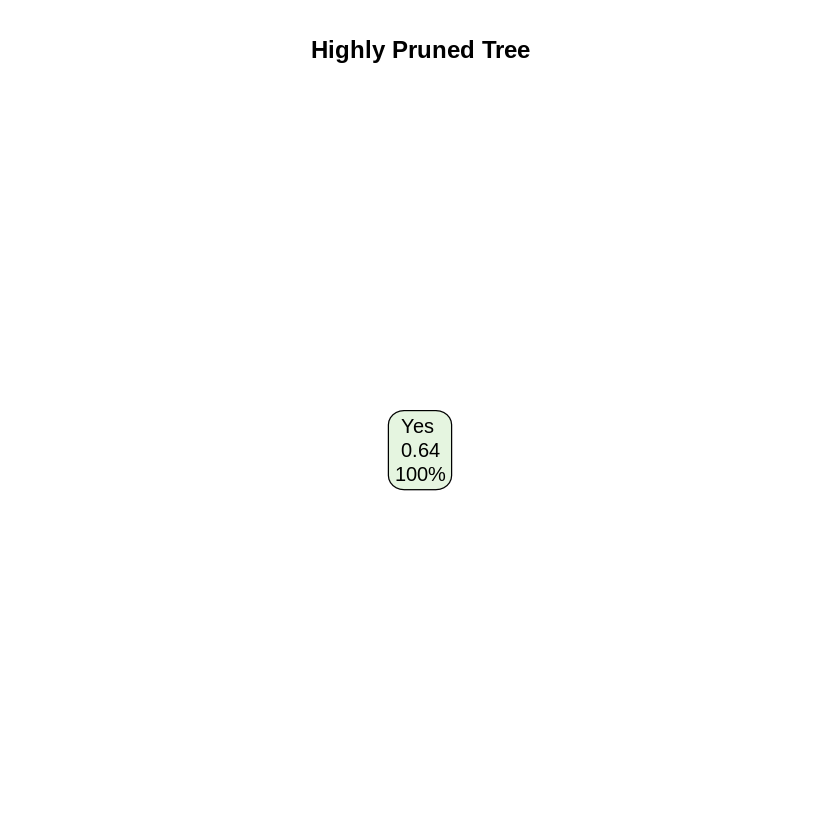

In [27]:
cart.model.highly.pruned = rpart (play~., data = weather.data,
                                  control = rpart.control (minsplit = 1, cp = 1))

rpart.plot (cart.model.highly.pruned,
             main = "Highly Pruned Tree")

Which tree is best?

Get all three confusion matrices (on the training data)

In [28]:
weather.predictions = predict (cart.model, weather.data, type = "class")
CF.1 = table (weather.data$play, weather.predictions)

weather.predictions = predict (cart.model.pruned, weather.data, type = "class")
CF.2 = table (weather.data$play, weather.predictions)

weather.predictions = predict (cart.model.highly.pruned, weather.data, type = "class")
CF.3 = table (weather.data$play, weather.predictions)

#Compare
CF.1
CF.2
CF.3


      weather.predictions
       No  Yes 
  No     5    0
  Yes    0    9

      weather.predictions
       No  Yes 
  No     4    1
  Yes    1    8

      weather.predictions
       No  Yes 
  No     0    5
  Yes    0    9

Can we conclude that one is better than the others? We can see that the least pruned tree (smallest cp value) has the lowest training error, but
a lower training error may not be better.

---

We can easily restrict the number of explanatory variables, say if
we only want to build a tree using Outlook and Windy (but with the default cp value).

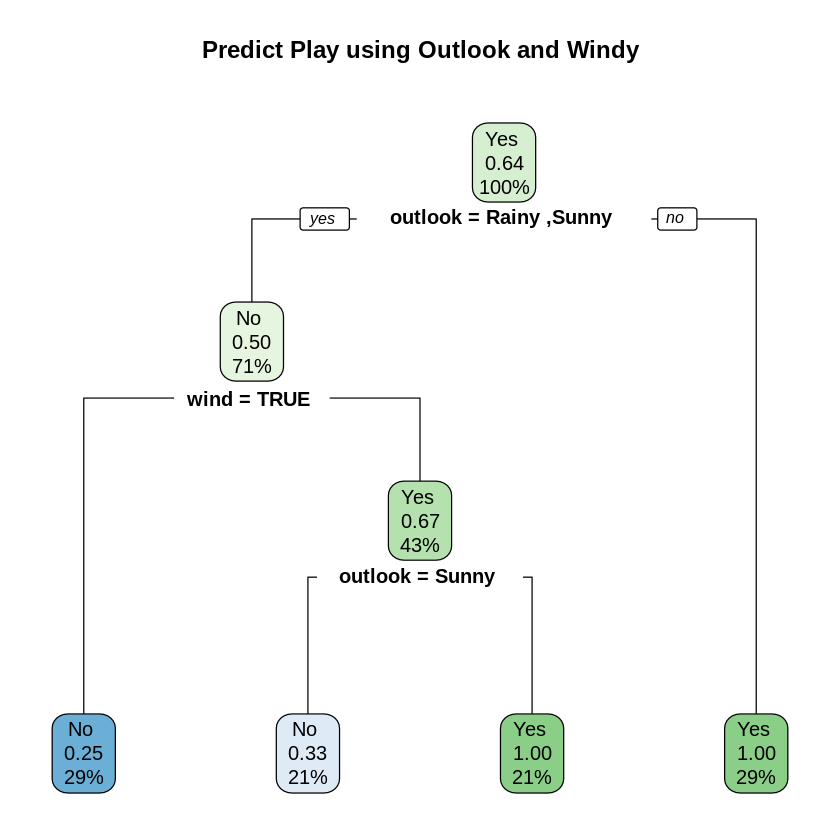

In [29]:
cart.model.simple = rpart (play~outlook+wind, data = weather.data,
                           control = rpart.control (minsplit = 1))

rpart.plot (cart.model.simple,
            main = "Predict Play using Outlook and Windy")

Let's evaluate the training error of this model

In [30]:
weather.predictions = predict (cart.model.simple, weather.data, type = "class")
CF.4 = table (weather.data$play, weather.predictions)
CF.4

      weather.predictions
       No  Yes 
  No     5    0
  Yes    2    7

How do we pick among the four DTs? we need to evaluate the TRUE ERROR, which is what we'll work on all of next week

#**KNN**

For knn, there are several options, including knn (class package) and knn3 (caret package)

In [31]:
pkgs <- c("caret")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [32]:
library(caret)

Loading required package: ggplot2

Loading required package: lattice



Make sure the class is a factor variable. Otherwise the function won't work

In [33]:
weather.data$play = factor (weather.data$play)

In [35]:
#By default k = 5
knn.model.5 = knn3 (play~., weather.data)
predictions5NN = predict (knn.model.5, weather.data, type = "class")
weather = cbind (weather.data, predictions5NN)
View (weather)

#For this tiny data, k = 5 is quite large!

outlook,temp,hum,wind,play,predictions5NN
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Sunny,Hot,High,FALSE,No,Yes
Sunny,Hot,High,TRUE,No,Yes
Overcast,Hot,High,FALSE,Yes,Yes
Rainy,Mild,High,FALSE,Yes,Yes
Rainy,Cool,Normal,FALSE,Yes,Yes
Rainy,Cool,Normal,TRUE,No,Yes
Overcast,Cool,Normal,TRUE,Yes,Yes
Sunny,Mild,High,FALSE,No,Yes
Sunny,Cool,Normal,FALSE,Yes,Yes


In [38]:
#For k =1, the training error will always be zero
knn.model.1 = knn3 (play~., weather.data, k=1)
predictions1NN = predict (knn.model.1, weather.data, type = "class")
weather = cbind (weather.data, predictions1NN, predictions5NN)
View (weather)

outlook,temp,hum,wind,play,predictions1NN,predictions5NN
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Sunny,Hot,High,FALSE,No,No,Yes
Sunny,Hot,High,TRUE,No,No,Yes
Overcast,Hot,High,FALSE,Yes,Yes,Yes
Rainy,Mild,High,FALSE,Yes,Yes,Yes
Rainy,Cool,Normal,FALSE,Yes,Yes,Yes
Rainy,Cool,Normal,TRUE,No,No,Yes
Overcast,Cool,Normal,TRUE,Yes,Yes,Yes
Sunny,Mild,High,FALSE,No,No,Yes
Sunny,Cool,Normal,FALSE,Yes,Yes,Yes


In [40]:
knn.model.3 = knn3(play~.,weather.data, k=3)
predictions3NN = predict(knn.model.3,weather.data,type="class")
weather = cbind(weather.data,predictions1NN,predictions3NN,predictions5NN)
View(weather)

outlook,temp,hum,wind,play,predictions1NN,predictions3NN,predictions5NN
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Sunny,Hot,High,FALSE,No,No,No,Yes
Sunny,Hot,High,TRUE,No,No,No,Yes
Overcast,Hot,High,FALSE,Yes,Yes,Yes,Yes
Rainy,Mild,High,FALSE,Yes,Yes,Yes,Yes
Rainy,Cool,Normal,FALSE,Yes,Yes,Yes,Yes
Rainy,Cool,Normal,TRUE,No,No,Yes,Yes
Overcast,Cool,Normal,TRUE,Yes,Yes,Yes,Yes
Sunny,Mild,High,FALSE,No,No,Yes,Yes
Sunny,Cool,Normal,FALSE,Yes,Yes,Yes,Yes


Confusion matrices for all three models. Which one is the best?

In [41]:
table (weather.data$play, predictions1NN) #Overfitting?
table (weather.data$play, predictions3NN) #Possibly "just right"?
table (weather.data$play, predictions5NN) #Underfitting?


      predictions1NN
       No  Yes 
  No     5    0
  Yes    0    9

      predictions3NN
       No  Yes 
  No     2    3
  Yes    0    9

      predictions5NN
       No  Yes 
  No     0    5
  Yes    0    9

Try first converting all the independent variables into dummy variables

In [42]:
pkgs <- c("fastDummies")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [43]:
library (fastDummies)

Dummy values are binary.
dummy_cols () functions identifies categorical columns and converts them into multiple new binary columns

In [50]:
View (dummy_cols (weather.data))

outlook,temp,hum,wind,play,outlook_Overcast,outlook_Rainy,outlook_Sunny,temp_Cool,temp_Hot,temp_Mild,hum_High,hum_Normal,wind_FALSE,wind_TRUE,play_No,play_Yes
<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Sunny,Hot,High,FALSE,No,0,0,1,0,1,0,1,0,1,0,1,0
Sunny,Hot,High,TRUE,No,0,0,1,0,1,0,1,0,0,1,1,0
Overcast,Hot,High,FALSE,Yes,1,0,0,0,1,0,1,0,1,0,0,1
Rainy,Mild,High,FALSE,Yes,0,1,0,0,0,1,1,0,1,0,0,1
Rainy,Cool,Normal,FALSE,Yes,0,1,0,1,0,0,0,1,1,0,0,1
Rainy,Cool,Normal,TRUE,No,0,1,0,1,0,0,0,1,0,1,1,0
Overcast,Cool,Normal,TRUE,Yes,1,0,0,1,0,0,0,1,0,1,0,1
Sunny,Mild,High,FALSE,No,0,0,1,0,0,1,1,0,1,0,1,0
Sunny,Cool,Normal,FALSE,Yes,0,0,1,1,0,0,0,1,1,0,0,1


In [55]:
#Select 5 to 15 columns from dummy_cols dataframe
weather.data.dum = dummy_cols (weather.data) [,5:15]

#Make sure the play column in new dataframe set as factor variable
weather.data.dum$play = factor (weather.data.dum$play)

# Reorder columns to put 'play' as the last column
column_names = colnames(weather.data.dum)
column_names = c(column_names[column_names != "play"], "play")
weather.data.dum = weather.data.dum[, column_names]

In [56]:
colnames (weather.data.dum)

[1] "outlook_Overcast " "outlook_Rainy "    "outlook_Sunny "   
 [4] "temp_Cool "        "temp_Hot "         "temp_Mild "       
 [7] "hum_High "         "hum_Normal "       "wind_FALSE "      
[10] "wind_TRUE "        "play"

In [58]:
#Select all columns except the 'play' column. %in% to match or check
x_predictors = weather.data.dum[, !(colnames(weather.data.dum) %in% c("play"))]
y_response = weather.data.dum$play

#another way to use knn3
knn.model.dum.5 = knn3 (x = x_predictors, y = y_response)

#because we train knn model using seperate predictors and response
#Now we apply the model directly on the predictors to predict response
predictions5NN.dum = predict (knn.model.dum.5, x_predictors, type = "class")
weather.dum = cbind (weather.data.dum, predictions5NN.dum)
View (weather.dum)

outlook_Overcast,outlook_Rainy,outlook_Sunny,temp_Cool,temp_Hot,temp_Mild,hum_High,hum_Normal,wind_FALSE,wind_TRUE,play,predictions5NN.dum
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>
0,0,1,0,1,0,1,0,1,0,No,Yes
0,0,1,0,1,0,1,0,0,1,No,No
1,0,0,0,1,0,1,0,1,0,Yes,Yes
0,1,0,0,0,1,1,0,1,0,Yes,Yes
0,1,0,1,0,0,0,1,1,0,Yes,Yes
0,1,0,1,0,0,0,1,0,1,No,Yes
1,0,0,1,0,0,0,1,0,1,Yes,Yes
0,0,1,0,0,1,1,0,1,0,No,Yes
0,0,1,1,0,0,0,1,1,0,Yes,Yes


In [59]:
knn.model.dum.1 = knn3 (x = x_predictors, y = y_response, k = 1)
predictions1NN.dum = predict (knn.model.dum.1, x_predictors, type = "class")
weather.dum = cbind (weather.data.dum, predictions1NN.dum, predictions5NN.dum)
View (weather.dum)

outlook_Overcast,outlook_Rainy,outlook_Sunny,temp_Cool,temp_Hot,temp_Mild,hum_High,hum_Normal,wind_FALSE,wind_TRUE,play,predictions1NN.dum,predictions5NN.dum
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>
0,0,1,0,1,0,1,0,1,0,No,No,Yes
0,0,1,0,1,0,1,0,0,1,No,No,No
1,0,0,0,1,0,1,0,1,0,Yes,Yes,Yes
0,1,0,0,0,1,1,0,1,0,Yes,Yes,Yes
0,1,0,1,0,0,0,1,1,0,Yes,Yes,Yes
0,1,0,1,0,0,0,1,0,1,No,No,Yes
1,0,0,1,0,0,0,1,0,1,Yes,Yes,Yes
0,0,1,0,0,1,1,0,1,0,No,No,Yes
0,0,1,1,0,0,0,1,1,0,Yes,Yes,Yes


In [60]:
knn.model.dum.3 = knn3 (x = x_predictors, y = y_response, k = 3)
predictions3NN.dum = predict (knn.model.dum.3, x_predictors, type = "class")
weather.dum = cbind (weather.data.dum, predictions1NN.dum, predictions3NN.dum,predictions5NN.dum)
View (weather.dum)

outlook_Overcast,outlook_Rainy,outlook_Sunny,temp_Cool,temp_Hot,temp_Mild,hum_High,hum_Normal,wind_FALSE,wind_TRUE,play,predictions1NN.dum,predictions3NN.dum,predictions5NN.dum
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>
0,0,1,0,1,0,1,0,1,0,No,No,No,Yes
0,0,1,0,1,0,1,0,0,1,No,No,No,No
1,0,0,0,1,0,1,0,1,0,Yes,Yes,Yes,Yes
0,1,0,0,0,1,1,0,1,0,Yes,Yes,No,Yes
0,1,0,1,0,0,0,1,1,0,Yes,Yes,Yes,Yes
0,1,0,1,0,0,0,1,0,1,No,No,Yes,Yes
1,0,0,1,0,0,0,1,0,1,Yes,Yes,Yes,Yes
0,0,1,0,0,1,1,0,1,0,No,No,No,Yes
0,0,1,1,0,0,0,1,1,0,Yes,Yes,Yes,Yes


In [64]:
table (weather.data.dum$play, predictions1NN.dum) # 1NN with dummy variables
table (weather.data.dum$play, predictions3NN.dum) # 3NN with dummy variables
table (weather.data.dum$play, predictions5NN.dum) # 5NN with dummy variables

      predictions1NN.dum
       No  Yes 
  No     5    0
  Yes    0    9

      predictions3NN.dum
       No  Yes 
  No     3    2
  Yes    1    8

      predictions5NN.dum
       No  Yes 
  No     2    3
  Yes    0    9

With repeated experiment using dummy variables, the results are different